<a href="https://colab.research.google.com/github/enilt/langgraph-alura/blob/main/Aula_08_MultiAg_Memoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 08 — Multiagentes com Memória (langmem) + Human-in-the-loop, com Groq

Evoluímos o assistente de e-mail da Aula 07 adicionando **memória semântica** (com `langmem`)
e um passo **human-in-the-loop** para decidir se agenda uma reunião.

> Convenções mantidas (com **Groq**):
> - Modelo **Groq** `openai/gpt-oss-120b` via `langchain-groq` (`reasoning_effort` explícito)
> - Chave automática (`GROQ_API_KEY`) via Secrets do Colab / `.env` / colada
>
> **Adaptações necessárias:**
> - O Groq **não fornece embeddings**. O original usava `GoogleGenerativeAIEmbeddings`.
>   Trocamos por **embeddings locais** (`sentence-transformers/all-MiniLM-L6-v2` via
>   `langchain-huggingface`), que rodam offline e **não precisam de chave** — assim a
>   busca semântica da memória continua funcionando de verdade.
> - `with_structured_output(Router)` usa `method="json_mode"` + instrução JSON (fix das aulas 06/07).
> - Esta aula **não usa Tavily**, então só a `GROQ_API_KEY` é necessária.

## 1. Instalação das dependências

In [1]:
%pip install -U langgraph langchain langchain-groq langmem langchain-huggingface sentence-transformers python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.2/65.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 52.5 MB/s eta 0:00:00
  Attempting uninstall: python-dotenv
    Found existing installation: python-dotenv 1.2.3
    Uninstalling python-dotenv-1.2.3:
      Successfully uninstalled python-dotenv-1.2.3
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.6.3
    Uninst

## 2. Importações

In [2]:
import os
import json
from pydantic import BaseModel
from typing_extensions import TypedDict, Literal, Annotated
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import ToolNode, create_react_agent
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langmem import create_manage_memory_tool, create_search_memory_tool
from langgraph.store.memory import InMemoryStore
from IPython.display import Image, display

## 3. Chave de API (sem digitar toda vez)

Esta aula usa **apenas o Groq**. Escolha: (1) **colar** o valor abaixo, (2) **Secrets do Colab** 🔑
(`GROQ_API_KEY` com "Notebook access", variável vazia), ou (3) arquivo **`.env`**.

In [3]:
GROQ_API_KEY = ""   # ex: "gsk_..." (opcional; vazio = Secrets do Colab / .env)


def resolver_chave(nome, valor_manual):
    if valor_manual:
        return valor_manual.strip()
    try:
        from google.colab import userdata
        try:
            v = userdata.get(nome)
            if v and v.strip():
                print(f"[OK] '{nome}' encontrada nos Secrets do Colab.")
                return v.strip()
            else:
                print(f"[VAZIO] '{nome}' existe nos Secrets, mas está vazia.")
        except userdata.SecretNotFoundError:
            print(f"[NAO EXISTE] '{nome}' não encontrada nos Secrets. Confira o NOME exato '{nome}'.")
        except userdata.NotebookAccessError:
            print(f"[SEM ACESSO] '{nome}' existe, mas 'Notebook access' NÃO está ativado.")
        except Exception as e:
            print(f"[ERRO] ao ler '{nome}' do Colab: {type(e).__name__}: {e}")
    except ImportError:
        pass
    try:
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass
    v = os.getenv(nome)
    return v.strip() if v else None


groq_key = resolver_chave("GROQ_API_KEY", GROQ_API_KEY)
if not groq_key:
    raise ValueError(
        "GROQ_API_KEY ausente. Cole na variável acima, ou crie o segredo no Colab "
        "(nome exato + Notebook access), ou defina no .env."
    )
os.environ["GROQ_API_KEY"] = groq_key
print("Chave carregada com sucesso!")

[OK] 'GROQ_API_KEY' encontrada nos Secrets do Colab.
Chave carregada com sucesso!


## 4. Perfil da usuária e instruções

In [4]:
# Perfil do usuário
profile = {
    "name": "Sarah",
    "full_name": "Sarah Chen",
    "user_profile_background": "Engenheira de software sênior liderando uma equipe de 5 desenvolvedores",
}

# Instruções para o prompt
prompt_instructions = {
    "triage_rules": {
        "ignore": "Newsletters, spam, comunicados gerais da empresa",
        "notify": "Membro da equipe doente, notificações do sistema de build, atualizações de status de projeto",
        "respond": "Perguntas diretas de membros da equipe, solicitações de reunião, relatórios de bugs críticos",
    },
    "agent_instructions": """Você é um assistente executivo altamente eficiente. Execute as tarefas solicitadas de forma direta, sem diálogos desnecessários. Responda apenas com a chamada das ferramentas, a menos que seja estritamente necessário fornecer uma resposta textual.

Tarefas:
- Responder ao e-mail de entrada.
- Salvar a tarefa de acompanhamento na memória.
- Sugerir uma próxima ação, como 'Gostaria que eu agendasse uma reunião para discutir isso?'"""
}

## 5. Modelo (Groq), roteador de triagem e prompts

In [5]:
# Modelo Groq reutilizado no roteador e no agente
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    reasoning_effort="low",
    max_retries=6,
)

# Roteador para classificar a intenção do e-mail
class Router(BaseModel):
    # Raciocínio por trás da classificação
    reasoning: str
    # Classificação do e-mail como 'ignorar', 'notificar' ou 'responder'
    classification: Literal["ignore", "notify", "respond"]

# json_mode: robusto com o gpt-oss no Groq (evita o erro de "tool choice")
llm_router = llm.with_structured_output(Router, method="json_mode")

# Instrução de formato anexada ao prompt do sistema (necessária no json_mode)
INSTRUCAO_JSON_ROUTER = (
    '\n\nIMPORTANTE: responda APENAS com um objeto JSON válido, sem texto extra, '
    'no formato: {"reasoning": "seu raciocínio", '
    '"classification": "ignore" ou "notify" ou "respond"}.'
)

# Prompt do sistema para a triagem de e-mails
triage_system_prompt = """Você é um assistente de triagem de e-mails.
Classifique os e-mails como 'ignore', 'notify' ou 'respond'.

Regras:
- ignore: {triage_no}
- notify: {triage_notify}
- respond: {triage_email}
"""

# Prompt do usuário, que contém os dados do e-mail
triage_user_prompt = """
De: {author}
Para: {to}
Assunto: {subject}
Corpo da Mensagem:
{email_thread}
"""

## 6. Ferramentas, memória semântica e agente ReAct

Aqui trocamos os embeddings do Google por **embeddings locais** (HuggingFace). O `InMemoryStore`
fica indexado por esses vetores, permitindo que `manage_memory`/`search_memory` (do `langmem`)
armazenem e busquem informações por similaridade semântica.

In [6]:
# --- Ferramentas ---
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Envia um e-mail para o destinatário especificado com o assunto e conteúdo fornecidos."""
    return json.dumps({"to": to, "subject": subject, "content": content})

@tool
def schedule_meeting(attendees: list[str], subject: str, duration_minutes: int, preferred_day: str) -> str:
    """Agenda uma reunião com os participantes especificados."""
    return f"Reunião '{subject}' agendada para {preferred_day} com {len(attendees)} participantes"

@tool
def check_calendar_availability(day: str) -> str:
    """Verifica os horários disponíveis para o dia fornecido."""
    return f"Horários disponíveis em {day}: 9:00, 14:00, 16:00"

In [7]:
# Embeddings LOCAIS (rodam offline, sem chave). Substituem o GoogleGenerativeAIEmbeddings.
# all-MiniLM-L6-v2 produz vetores de 384 dimensões.
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
store = InMemoryStore(index={"embed": embeddings, "dims": 384})

manage_memory_tool = create_manage_memory_tool(
    store=store,
    namespace=("email_assistant", "{langgraph_user_id}", "collection")
)
search_memory_tool = create_search_memory_tool(
    store=store,
    namespace=("email_assistant", "{langgraph_user_id}", "collection")
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
agent_system_prompt_memory = """
< Função >
Você é o(a) assistente executivo(a) de {full_name}. Sua prioridade é maximizar o desempenho de {name}.
{instructions}
</ Função >

< Ferramentas >
1. write_email(to, subject, content) - Envia e-mails
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day) - Agenda reuniões
3. check_calendar_availability(day) - Verifica horários disponíveis
4. manage_memory - Armazena informações na memória
5. search_memory - Busca informações na memória
</ Ferramentas >
"""

def create_prompt(state):
    return [
        {"role": "system", "content": agent_system_prompt_memory.format(
            instructions=prompt_instructions["agent_instructions"], **profile
        )},
    ] + state['messages']

tools = [write_email, schedule_meeting, check_calendar_availability, manage_memory_tool, search_memory_tool]

response_agent = create_react_agent(
    model=llm,
    tools=tools,
    prompt=create_prompt,
    store=store
)

/tmp/ipykernel_2376/2001368758.py:25: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  response_agent = create_react_agent(


## 7. Estado e nó de triagem

> Pequeno ajuste necessário: em vez de gravar a rota numa chave `__next__` (fora do schema do estado),
> declaramos o campo `route` no `State` e roteamos por ele. Isso mantém exatamente o mesmo
> comportamento (respond → agente; ignore/notify → fim), porém compatível com o LangGraph atual.

In [9]:
class State(TypedDict):
    email_input: dict
    messages: Annotated[list, add_messages]
    route: str

def triage_router(state: State) -> dict:
    author = state['email_input']['from']
    to = state['email_input']['to']
    subject = state['email_input']['subject']
    body = state['email_input']['body']

    system_prompt = triage_system_prompt.format(
        triage_no=prompt_instructions["triage_rules"]["ignore"],
        triage_notify=prompt_instructions["triage_rules"]["notify"],
        triage_email=prompt_instructions["triage_rules"]["respond"]
    )
    user_prompt = triage_user_prompt.format(
        author=author,
        to=to,
        subject=subject,
        email_thread=body
    )
    result = llm_router.invoke(
        [{"role": "system", "content": system_prompt + INSTRUCAO_JSON_ROUTER},
         {"role": "user", "content": user_prompt}]
    )

    if result.classification == "respond":
        message_content = json.dumps({
            "sender": author,
            "recipient": to,
            "subject": subject,
            "body": body
        })
        return {
            "messages": [
                HumanMessage(content=f"Respond to the email {message_content}")
            ],
            "route": "response_agent"
        }
    elif result.classification in ["ignore", "notify"]:
        return {"route": "end"}
    else:
        raise ValueError(f"Invalid classification: {result.classification}")

## 8. Construção do grafo

In [10]:
builder = StateGraph(State)
builder.add_node("triage_router", triage_router)
builder.add_node("response_agent", response_agent)
builder.add_node("tool_node", ToolNode(tools))
builder.set_entry_point("triage_router")

# Roteamento após a triagem
builder.add_conditional_edges(
    "triage_router",
    lambda state: state.get("route", "end"),
    {"response_agent": "response_agent", "end": END}
)

def route_to_tools(state):
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tool_node"
    return END

builder.add_conditional_edges(
    "response_agent",
    route_to_tools,
    {"tool_node": "tool_node", END: END}
)
builder.add_edge("tool_node", "response_agent")

email_agent = builder.compile()

## 9. Visualização do grafo

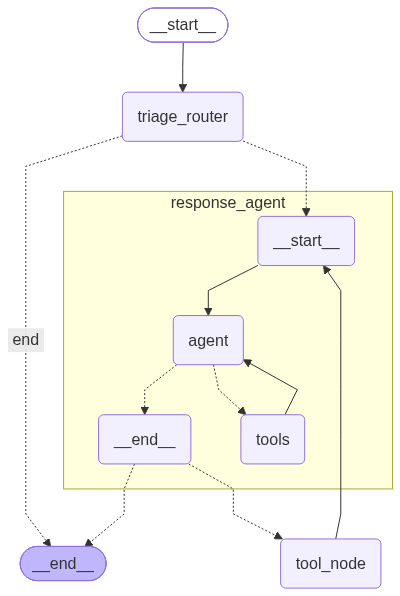

In [ ]:
display(Image(email_agent.get_graph(xray=True).draw_mermaid_png()))

## 10. Human-in-the-loop (decisão de agendar reunião)

In [11]:
def human_in_the_loop_schedule(email_sender, email_recipient, email_subject):
    # Checa memória se já há reunião
    search_results = search_memory_tool.invoke(
        {"query": f"Reunião agendada para {email_sender}"},
        config=config
    )
    if isinstance(search_results, str):
        # retorna string, transforma em dict vazio
        search_results = {}

    if isinstance(search_results, dict) and search_results.get("results"):
        email_content = write_email.invoke(
            {
                "to": email_sender,
                "subject": f"Re: {email_subject}",
                "content": "Olá, acabei de agendar uma conversa contigo para discutirmos esse assunto."
            },
            config=config
        )
        print("================== Tool Message ==================")
        print(f"Name: write_email\nContent: {email_content}")
        return

    decision = input(f"Deseja agendar uma reunião para discutir o pedido de {email_sender}? (sim/não): ").strip().lower()

    if decision == "sim":
        meeting_output = schedule_meeting.invoke(
            {
                "attendees": [email_recipient.split('<')[0].strip(), email_sender.split('<')[0].strip()],
                "subject": f"Acompanhamento do pedido de {email_sender}",
                "duration_minutes": 30,
                "preferred_day": "amanhã"
            },
            config=config
        )
        print("================== Tool Message ==================")
        print(f"Name: schedule_meeting\nContent: {meeting_output}")

        memory_output = manage_memory_tool.invoke(
            {"action": "create", "content": f"Reunião agendada para discutir o pedido de {email_sender}"},
            config=config
        )
        print("================== Tool Message ==================")
        print(f"Name: manage_memory\nContent: {memory_output}")

        email_content = write_email.invoke(
            {
                "to": email_sender,
                "subject": f"Re: {email_subject}",
                "content": "Já agendei uma reunião contigo para discutirmos esse assunto."
            },
            config=config
        )
        print("================== Tool Message ==================")
        print(f"Name: write_email\nContent: {email_content}")

    else:
        email_content = write_email.invoke(
            {
                "to": email_sender,
                "subject": f"Re: {email_subject}",
                "content": "Estou acompanhando seu pedido e entrarei em contato assim que houver novidades."
            },
            config=config
        )
        print("================== Tool Message ==================")
        print(f"Name: write_email\nContent: {email_content}")

        memory_output = manage_memory_tool.invoke(
            {"action": "create", "content": f"E-mail de acompanhamento enviado para {email_sender}"},
            config=config
        )
        print("================== Tool Message ==================")
        print(f"Name: manage_memory\nContent: {memory_output}")

## 11. Exemplo de execução

In [13]:
config = {"configurable": {"langgraph_user_id": "lance"}}

# Pré-popula a memória
initial_memory_content = "Acompanhamento necessário: Alice Smith perguntou sobre os endpoints de API ausentes na documentação do serviço de autenticação (/auth/refresh e /auth/validate). Sarah precisa revisar e esclarecer se eles foram intencionalmente omitidos ou se a documentação precisa de atualização."
manage_memory_tool.invoke({"action": "create", "content": initial_memory_content}, config=config)

email_input = {
    "from": "Alice Smith <alice.smith@company.com>",
    "to": "Sarah Chen <sarah.chen@company.com>",
    "subject": "Acompanhamento",
    "body": "Olá Sarah, como está minha solicitação?"
}

# 1) Agente responde
response = email_agent.invoke({"email_input": email_input}, config=config)
for msg in response["messages"]:
    if isinstance(msg, ToolMessage):
        print("================== Mensagem da Ferramenta ==================")
        print(f"Nome: {msg.name}\nConteúdo: {msg.content}")

# 2) Human-in-the-loop
human_in_the_loop_schedule(email_input["from"], email_input["to"], email_input["subject"])

================== Mensagem da Ferramenta ==================
Nome: write_email
Conteúdo: {"to": "alice.smith@company.com", "subject": "Re: Acompanhamento", "content": "Ol\u00e1 Alice,\n\nObrigado por entrar em contato. Estou verificando o status da sua solicita\u00e7\u00e3o e retornarei em breve com uma atualiza\u00e7\u00e3o.\n\nAtenciosamente,\nSarah Chen"}
================== Mensagem da Ferramenta ==================
Nome: manage_memory
Conteúdo: created memory 56adc47c-a6e0-49d2-a80f-49f9f5bb004d
Deseja agendar uma reunião para discutir o pedido de Alice Smith <alice.smith@company.com>? (sim/não): nao
================== Tool Message ==================
Name: write_email
Content: {"to": "Alice Smith <alice.smith@company.com>", "subject": "Re: Acompanhamento", "content": "Estou acompanhando seu pedido e entrarei em contato assim que houver novidades."}
================== Tool Message ==================
Name: manage_memory
Content: created memory 761d9b20-2849-46d2-9416-aa281299712e
